In [1]:
import pandas as pd
import csv
import numpy as np
import os
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

In [5]:
os.chdir('..')

In [6]:
pwd

'/home/pribus/ONTBC_analysis'

In [8]:
# read in the supplementary table A with clinical data
clin_df = pd.read_csv('013026_clin_table.csv')

In [9]:
clin_df = clin_df[["Sample", "Grade", "Grade (#)", "NMIBC/MIBC", "Age", "Sex", "Smoking", "L1 insertion count"]]

In [10]:
clin_df = clin_df[clin_df['L1 insertion count'].notna()]

In [12]:
## AGE

# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(clin_df['Age'], clin_df['L1 insertion count'])
print(f"Age vs L1 insertion count: Pearson r = {pearson_r:.2f}, p = {pearson_p:.3f}")

# Spearman correlation (non-parametric)
spearman_r, spearman_p = stats.spearmanr(clin_df['Age'], clin_df['L1 insertion count'])
print(f"Age vs L1 insertion count: Spearman r = {spearman_r:.2f}, p = {spearman_p:.3f}")

Age vs L1 insertion count: Pearson r = -0.07, p = 0.760
Age vs L1 insertion count: Spearman r = 0.17, p = 0.451


In [13]:
## Sex

group1 = clin_df[clin_df['Sex'] == 'M']['L1 insertion count']
group2 = clin_df[clin_df['Sex'] == 'F']['L1 insertion count']

u_stat, p_val = stats.mannwhitneyu(group1, group2, alternative='two-sided')
print(f"Sex vs L1 insertion count: U = {u_stat}, p = {p_val:.3f}")

Sex vs L1 insertion count: U = 44.5, p = 0.905


In [14]:
## Grade

group1 = clin_df[clin_df['Grade'] == 'high']['L1 insertion count']
group2 = clin_df[clin_df['Grade'] == 'low']['L1 insertion count']

u_stat, p_val = stats.mannwhitneyu(group1, group2, alternative='two-sided')
print(f"Grade vs L1 insertion count: U = {u_stat}, p = {p_val:.3f}")

Grade vs L1 insertion count: U = 84.0, p = 0.020


In [15]:
## Stage

group1 = clin_df[clin_df['NMIBC/MIBC'] == 'NMIBC']['L1 insertion count']
group2 = clin_df[clin_df['NMIBC/MIBC'] == 'MIBC']['L1 insertion count']

u_stat, p_val = stats.mannwhitneyu(group1, group2, alternative='two-sided')
print(f"Stage vs L1 insertion count: U = {u_stat}, p = {p_val:.3f}")

Stage vs L1 insertion count: U = 37.5, p = 0.086


In [16]:
## Smoking

group1 = clin_df[clin_df['Smoking'] == 'yes']['L1 insertion count']
group2 = clin_df[clin_df['Smoking'] == 'no']['L1 insertion count']

u_stat, p_val = stats.mannwhitneyu(group1, group2, alternative='two-sided')
print(f"Smoking vs L1 insertion count: U = {u_stat}, p = {p_val:.3f}")

Smoking vs L1 insertion count: U = 76.0, p = 0.079


In [17]:
## Grade (#)

groups = [clin_df[clin_df['Grade (#)'] == g]['L1 insertion count'] for g in clin_df['Grade (#)'].unique()]
h_stat, p_val = stats.kruskal(*groups)
print(f"Grade vs L1 insertion count: H = {h_stat}, p = {p_val:.3f}")

Grade vs L1 insertion count: H = 4.796129255227229, p = 0.091


In [18]:
clin_df['L1_high'] = clin_df['L1 insertion count'].apply(lambda x: 'high' if x >= 15 else 'low' if pd.notna(x) else None)

Chi-square p-value: 0.3544


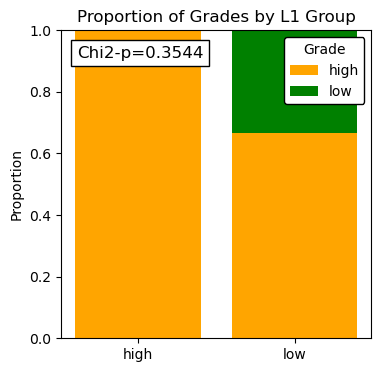

In [19]:
# Create contingency table
cont_table = pd.crosstab(clin_df['L1_high'], clin_df['Grade'])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(cont_table)
print(f"Chi-square p-value: {p:.4f}")

color_map = {
    'high': 'orange',
    'low': 'green',
}

# Plot
groups = clin_df['L1_high'].unique()
categories = clin_df['Grade'].unique()
bottoms = {grp: 0 for grp in groups}

fig, ax = plt.subplots(figsize=(4,4))
for cat in categories:
    heights = [
        (clin_df[(clin_df['L1_high']==grp) & (clin_df['Grade']==cat)].shape[0] / clin_df[clin_df['L1_high']==grp].shape[0])
        if clin_df[clin_df['L1_high']==grp].shape[0] > 0 else 0
        for grp in groups
    ]
    ax.bar(groups, heights, bottom=[bottoms[grp] for grp in groups],
           color=color_map.get(cat, '#cccccc'), label=cat)
    
    for i, grp in enumerate(groups):
        bottoms[grp] += heights[i]

ax.set_ylabel('Proportion')
ax.set_title('Proportion of Grades by L1 Group')

# Add Chi-square p-value
plt.text(0.05, 0.95, f'Chi2-p={p:.4f}', transform=plt.gca().transAxes,
         ha='left', va='top', fontsize=12, color='black', bbox=dict(facecolor='white', alpha=1))

legend = ax.legend(title='Grade')
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_alpha(1)

plt.show()

Chi-square p-value: 0.7395


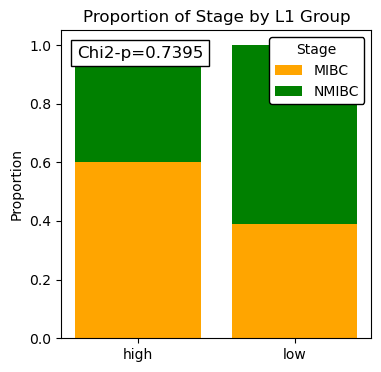

In [20]:
# Create contingency table
cont_table = pd.crosstab(clin_df['L1_high'], clin_df['NMIBC/MIBC'])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(cont_table)
print(f"Chi-square p-value: {p:.4f}")

color_map = {
    'MIBC': 'orange',
    'NMIBC': 'green',
}

# Plot
groups = clin_df['L1_high'].unique()
categories = clin_df['NMIBC/MIBC'].unique()
bottoms = {grp: 0 for grp in groups}

fig, ax = plt.subplots(figsize=(4,4))
for cat in categories:
    heights = [
        (clin_df[(clin_df['L1_high']==grp) & (clin_df['NMIBC/MIBC']==cat)].shape[0] / clin_df[clin_df['L1_high']==grp].shape[0])
        if clin_df[clin_df['L1_high']==grp].shape[0] > 0 else 0
        for grp in groups
    ]
    ax.bar(groups, heights, bottom=[bottoms[grp] for grp in groups],
           color=color_map.get(cat, '#cccccc'), label=cat)
    
    for i, grp in enumerate(groups):
        bottoms[grp] += heights[i]

ax.set_ylabel('Proportion')
ax.set_title('Proportion of Stage by L1 Group')

# Add Chi-square p-value
plt.text(0.05, 0.95, f'Chi2-p={p:.4f}', transform=plt.gca().transAxes,
         ha='left', va='top', fontsize=12, color='black', bbox=dict(facecolor='white', alpha=1))

legend = ax.legend(title='Stage')
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_alpha(1)

plt.show()

Chi-square p-value: 0.3544


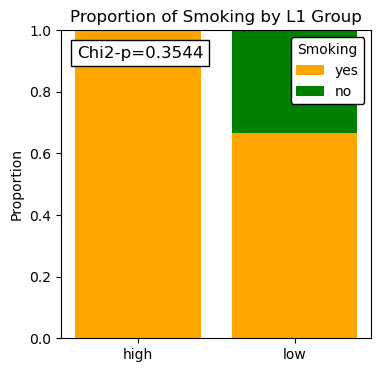

In [21]:
# Create contingency table
cont_table = pd.crosstab(clin_df['L1_high'], clin_df['Smoking'])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(cont_table)
print(f"Chi-square p-value: {p:.4f}")

color_map = {
    'yes': 'orange',
    'no': 'green',
}

# Plot
groups = clin_df['L1_high'].unique()
categories = clin_df['Smoking'].unique()
bottoms = {grp: 0 for grp in groups}

fig, ax = plt.subplots(figsize=(4,4))
for cat in categories:
    heights = [
        (clin_df[(clin_df['L1_high']==grp) & (clin_df['Smoking']==cat)].shape[0] / clin_df[clin_df['L1_high']==grp].shape[0])
        if clin_df[clin_df['L1_high']==grp].shape[0] > 0 else 0
        for grp in groups
    ]
    ax.bar(groups, heights, bottom=[bottoms[grp] for grp in groups],
           color=color_map.get(cat, '#cccccc'), label=cat)
    
    for i, grp in enumerate(groups):
        bottoms[grp] += heights[i]

ax.set_ylabel('Proportion')
ax.set_title('Proportion of Smoking by L1 Group')

# Add Chi-square p-value
plt.text(0.05, 0.95, f'Chi2-p={p:.4f}', transform=plt.gca().transAxes,
         ha='left', va='top', fontsize=12, color='black', bbox=dict(facecolor='white', alpha=1))

legend = ax.legend(title='Smoking')
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_alpha(1)

plt.show()

Chi-square p-value: 0.8527


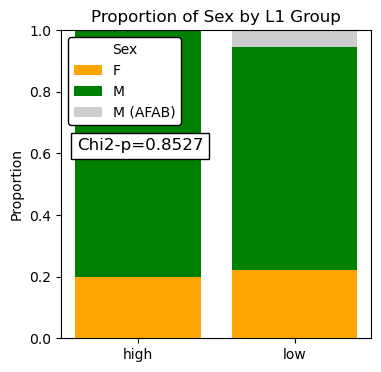

In [22]:
# Create contingency table
cont_table = pd.crosstab(clin_df['L1_high'], clin_df['Sex'])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(cont_table)
print(f"Chi-square p-value: {p:.4f}")

color_map = {
    'F': 'orange',
    'M': 'green',
}

# Plot
groups = clin_df['L1_high'].unique()
categories = clin_df['Sex'].unique()
bottoms = {grp: 0 for grp in groups}

fig, ax = plt.subplots(figsize=(4,4))
for cat in categories:
    heights = [
        (clin_df[(clin_df['L1_high']==grp) & (clin_df['Sex']==cat)].shape[0] / clin_df[clin_df['L1_high']==grp].shape[0])
        if clin_df[clin_df['L1_high']==grp].shape[0] > 0 else 0
        for grp in groups
    ]
    ax.bar(groups, heights, bottom=[bottoms[grp] for grp in groups],
           color=color_map.get(cat, '#cccccc'), label=cat)
    
    for i, grp in enumerate(groups):
        bottoms[grp] += heights[i]

ax.set_ylabel('Proportion')
ax.set_title('Proportion of Sex by L1 Group')

# Add Chi-square p-value
plt.text(0.05, 0.65, f'Chi2-p={p:.4f}', transform=plt.gca().transAxes,
         ha='left', va='top', fontsize=12, color='black', bbox=dict(facecolor='white', alpha=1))

legend = ax.legend(title='Sex')
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_alpha(1)

plt.show()